In [1]:
#Importing libraries ---------------
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
import calendar
import statsmodels.api as sm

In [2]:
#Reading the dataset ---------------
dt = pd.read_csv("C:/Users/jband/Documents/python_2026/project_delivery_drivers/uber-eats-deliveries.csv")

dt.head(5)

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19/03/2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25/03/2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19/03/2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05/04/2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26/03/2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


In [3]:
# get some light eda of the dataset

print(f"{dt.shape}")
print(f"{dt.columns}")
print(f"{dt.info()}")

(45593, 20)
Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  object 
 3   Delivery_person_Ratings      45593 non-null  object 
 4   Restaurant_latitude          45593 non-null  float64
 

In [4]:
# do some more light eda before feature engineering

import statistics
from scipy import stats

# Strip whitespace from all string columns
dt = dt.apply(lambda col: col.str.strip() if col.dtype == "object" else col)

dt = dt.replace(['NaN', 'nan', 'None', 'n/a', '', ' '], np.nan) # replace string as missing values

null = dt.isnull().sum()
nan = dt.isna().sum()
dup = dt.duplicated().sum()

print(f"Nan: {nan}")
print(f"dup: {dup}")

# We can see that there's nan values in the features. 
# We may need to interpolate for the EDA/Hypothesis testing and model analysis.

Nan: ID                                0
Delivery_person_ID                0
Delivery_person_Age            1854
Delivery_person_Ratings        1908
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1731
Time_Order_picked                 0
Weatherconditions                 0
Road_traffic_density            601
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             993
Festival                        228
City                           1200
Time_taken(min)                   0
dtype: int64
dup: 0


In [5]:
#external variables only - we need to map these later

dt_copy = dt[['Weatherconditions','Road_traffic_density',
              'Type_of_order','Type_of_vehicle','multiple_deliveries',
              'Festival','City']].copy()

for x in dt_copy:
    print(f"{x} unique values: {dt_copy[x].unique()}")

Weatherconditions unique values: ['conditions Sunny' 'conditions Stormy' 'conditions Sandstorms'
 'conditions Cloudy' 'conditions Fog' 'conditions Windy' 'conditions NaN']
Road_traffic_density unique values: ['High' 'Jam' 'Low' 'Medium' nan]
Type_of_order unique values: ['Snack' 'Drinks' 'Buffet' 'Meal']
Type_of_vehicle unique values: ['motorcycle' 'scooter' 'electric_scooter' 'bicycle']
multiple_deliveries unique values: ['0' '1' '3' nan '2']
Festival unique values: ['No' 'Yes' nan]
City unique values: ['Urban' 'Metropolitian' 'Semi-Urban' nan]


In [6]:
#tweak time as it needs to be in a 00:00 hr format and combine date/time

dt['dttm'] = dt['Order_Date'] + dt['Time_Order_picked']

dt['dttm'] = pd.to_datetime(dt['dttm'], format='%d/%m/%Y%H:%M:%S')

dt['dttm_floored'] = dt['dttm'].dt.floor('h') # round down the time

# sort the data 
dt = dt.sort_values('dttm_floored')

dt.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,...,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),dttm,dttm_floored
608,0xd152,BHPRES15DEL03,38,4.8,23.234249,77.434007,23.294249,77.494007,11/02/2022,00:00:00,...,Low,1,Meal,scooter,1,No,Urban,(min) 17,2022-02-11 00:10:00,2022-02-11
21735,0xc801,AURGRES07DEL03,35,NaN,19.875908,75.358888,19.935908,75.418888,11/02/2022,23:45:00,...,Low,1,Meal,motorcycle,0,No,Metropolitian,(min) 29,2022-02-11 00:00:00,2022-02-11
13108,0xe256,LUDHRES010DEL02,32,4.3,30.892860,75.822199,30.942860,75.872199,11/02/2022,23:55:00,...,Low,0,Drinks,motorcycle,0,No,Metropolitian,(min) 32,2022-02-11 00:00:00,2022-02-11
21019,0xe27f,ALHRES15DEL02,31,4.4,25.449872,81.836167,25.499872,81.886167,11/02/2022,23:55:00,...,Low,0,Meal,motorcycle,1,No,Urban,(min) 24,2022-02-11 00:10:00,2022-02-11
39093,0xe093,KOLRES08DEL03,28,5,22.537960,88.349843,22.567960,88.379843,11/02/2022,23:50:00,...,Low,0,Meal,motorcycle,0,No,Metropolitian,(min) 17,2022-02-11 00:05:00,2022-02-11


In [7]:
#tweak time taken because its a string

dt['Time_taken(min)'] = dt['Time_taken(min)'].str.split().str[-1].astype(int)

dt.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45593 entries, 608 to 44856
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   ID                           45593 non-null  object        
 1   Delivery_person_ID           45593 non-null  object        
 2   Delivery_person_Age          43739 non-null  object        
 3   Delivery_person_Ratings      43685 non-null  object        
 4   Restaurant_latitude          45593 non-null  float64       
 5   Restaurant_longitude         45593 non-null  float64       
 6   Delivery_location_latitude   45593 non-null  float64       
 7   Delivery_location_longitude  45593 non-null  float64       
 8   Order_Date                   45593 non-null  object        
 9   Time_Orderd                  43862 non-null  object        
 10  Time_Order_picked            45593 non-null  object        
 11  Weatherconditions            45593 non-null 

In [8]:
# we need to create a derived time series variable as our target variable - we will do hourly time series

driver_count = dt.groupby('dttm_floored').size().to_frame(name='deliveries_this_hour')

#also adding the average time per delivery in that hour
driver_count['avg_time'] = dt.groupby('dttm_floored')['Time_taken(min)'].mean().round(2)

driver_count = driver_count.reset_index()

driver_count

,dttm_floored,deliveries_this_hour,avg_time
0,2022-02-11 00:00:00,19,20.05
1,2022-02-11 08:00:00,41,18.71
2,2022-02-11 09:00:00,104,19.35
3,2022-02-11 10:00:00,86,19.87
4,2022-02-11 11:00:00,74,24.31
...,...,...,...
545,2022-04-06 19:00:00,142,33.46
546,2022-04-06 20:00:00,147,32.78
547,2022-04-06 21:00:00,116,32.18
548,2022-04-06 22:00:00,142,27.06


In [9]:
# Since we are using a time series model we need to make sure the data set has a continuous time.
# e.g, 0 hour to 23 hour

# 1. Set index
driver_count = driver_count.set_index('dttm_floored')
driver_count = driver_count.sort_index()

# 2. Create FULL 24-hour hourly index
full_index = pd.date_range(
    start=driver_count.index.min(),
    end=driver_count.index.max(),
    freq='h'
)

driver_count = driver_count.reindex(full_index)
driver_count.index.name = 'dttm_floored'

# 3. Define and create external variable called closed hours..
# .. there is a trend in the data where 0 deliveries were made during these times..
# .. because the restaurants were closed.
closed_hours = [1,2,3,4,5,6,7]

is_closed = driver_count.index.hour.isin(closed_hours) # creates boolean mask to deterimine closing hours
is_open = ~is_closed # creates the opposite mask to determine opening hours

cols = ['deliveries_this_hour', 'avg_time']

# 4. Fill ONLY closed hours with 0 - we want these to be reflecting true 0 values
driver_count.loc[is_closed, cols] = (
    driver_count.loc[is_closed, cols].fillna(0)
)

driver_count_clean = driver_count.copy()

driver_count_clean

,deliveries_this_hour,avg_time
dttm_floored,,
2022-02-11 00:00:00,19.0,20.05
2022-02-11 01:00:00,0.0,0.00
2022-02-11 02:00:00,0.0,0.00
2022-02-11 03:00:00,0.0,0.00
2022-02-11 04:00:00,0.0,0.00
...,...,...
2022-04-06 19:00:00,142.0,33.46
2022-04-06 20:00:00,147.0,32.78
2022-04-06 21:00:00,116.0,32.18


In [10]:
# test the copy dataset and see if nan values are true

driver_count_clean['month'] = driver_count_clean.index.month_name()

driver_count_clean.tail(24)

,deliveries_this_hour,avg_time,month
dttm_floored,,,
2022-04-06 00:00:00,33.0,25.76,April
2022-04-06 01:00:00,0.0,0.00,April
2022-04-06 02:00:00,0.0,0.00,April
2022-04-06 03:00:00,0.0,0.00,April
2022-04-06 04:00:00,0.0,0.00,April
2022-04-06 05:00:00,0.0,0.00,April
2022-04-06 06:00:00,0.0,0.00,April
2022-04-06 07:00:00,0.0,0.00,April
2022-04-06 08:00:00,NaN,NaN,April


In [11]:
#figure out which has 0 days from the asfreq

driver_count['date'] = driver_count.index.date
zero_days = driver_count.groupby('date')['deliveries_this_hour'].sum()
zero_days = zero_days[zero_days == 0].index

print(len(zero_days) / driver_count['date'].nunique())

driver_count = driver_count.drop(columns=['date'])

# since 11 out of 55 days are 0 obs (20%). 
# These were retained and encoded as non-operational days to preserve temporal structure.

0.2


In [12]:
#lets create the target variable now which is predicting the number of drivers required

#capacity per driver: We assume 2 deliveries per driver per hour as a conservative estimate 
#... of urban delivery capacity under mixed traffic and batching conditions
capacity_per_driver = 2

#find out how many drivers can do that hour - target
driver_count['drivers_this_hour'] = np.ceil(driver_count['deliveries_this_hour'] / capacity_per_driver)

driver_count

,deliveries_this_hour,avg_time,drivers_this_hour
dttm_floored,,,
2022-02-11 00:00:00,19.0,20.05,10.0
2022-02-11 01:00:00,0.0,0.00,0.0
2022-02-11 02:00:00,0.0,0.00,0.0
2022-02-11 03:00:00,0.0,0.00,0.0
2022-02-11 04:00:00,0.0,0.00,0.0
...,...,...,...
2022-04-06 19:00:00,142.0,33.46,71.0
2022-04-06 20:00:00,147.0,32.78,74.0
2022-04-06 21:00:00,116.0,32.18,58.0


In [13]:
#add extra variables to this target dataset based on the dttm_floored

driver_count['hour'] = driver_count.index.hour
driver_count['day_of_week'] = driver_count.index.dayofweek
driver_count['day_name'] = driver_count.index.day_name()
driver_count['is_weekend'] = driver_count['day_of_week'].isin([5,6]).astype(int)

# we want to create an exogenous variable to determine if the shop has opened (1) or not (0)
driver_count['is_open'] = (
    (driver_count['hour'] == 0).astype(int) |
    ((driver_count["hour"] >= 8) & (driver_count["hour"] <= 23)).astype(int))

driver_count.head()

,deliveries_this_hour,avg_time,drivers_this_hour,hour,day_of_week,day_name,is_weekend,is_open
dttm_floored,,,,,,,,
2022-02-11 00:00:00,19.0,20.05,10.0,0,4,Friday,0,1
2022-02-11 01:00:00,0.0,0.00,0.0,1,4,Friday,0,0
2022-02-11 02:00:00,0.0,0.00,0.0,2,4,Friday,0,0
2022-02-11 03:00:00,0.0,0.00,0.0,3,4,Friday,0,0
2022-02-11 04:00:00,0.0,0.00,0.0,4,4,Friday,0,0


In [14]:
#add historical dependency - lag features 

driver_count['driver_lag_1'] = driver_count['drivers_this_hour'].shift(1)
driver_count['driver_lag_24'] = driver_count['drivers_this_hour'].shift(24)
driver_count['driver_lag_168'] = driver_count['drivers_this_hour'].shift(168)

driver_count.head()

,deliveries_this_hour,avg_time,drivers_this_hour,hour,day_of_week,day_name,is_weekend,is_open,driver_lag_1,driver_lag_24,driver_lag_168
dttm_floored,,,,,,,,,,,
2022-02-11 00:00:00,19.0,20.05,10.0,0,4,Friday,0,1,NaN,NaN,NaN
2022-02-11 01:00:00,0.0,0.00,0.0,1,4,Friday,0,0,10.0,NaN,NaN
2022-02-11 02:00:00,0.0,0.00,0.0,2,4,Friday,0,0,0.0,NaN,NaN
2022-02-11 03:00:00,0.0,0.00,0.0,3,4,Friday,0,0,0.0,NaN,NaN
2022-02-11 04:00:00,0.0,0.00,0.0,4,4,Friday,0,0,0.0,NaN,NaN


In [15]:
# add rolling features - They help the model understand the recent behaviour of demand
# rolling mean → “How busy has it been recently on average?”
# rolling std → “How unstable or unpredictable has it been recently?” (low std = demand is predictable, high std = demand is unpredictable)
# the key is min_periods where it only calculate the value if all 24 hours exist,
# .. this is due to handling NaN values

driver_count['driver_rolling_mean_24'] = (driver_count['drivers_this_hour']
                                   .rolling(window=24,min_periods=24)
                                   .mean().round())
driver_count['driver_rolling_std_24'] = (driver_count['drivers_this_hour']
                                  .rolling(window=24,min_periods=24)
                                  .std().round())


driver_count.tail(48)

,deliveries_this_hour,avg_time,drivers_this_hour,hour,day_of_week,day_name,is_weekend,is_open,driver_lag_1,driver_lag_24,driver_lag_168,driver_rolling_mean_24,driver_rolling_std_24
dttm_floored,,,,,,,,,,,,,
2022-04-05 00:00:00,24.0,18.38,12.0,0,1,Tuesday,0,1,75.0,18.0,20.0,NaN,NaN
2022-04-05 01:00:00,0.0,0.00,0.0,1,1,Tuesday,0,0,12.0,0.0,0.0,NaN,NaN
2022-04-05 02:00:00,0.0,0.00,0.0,2,1,Tuesday,0,0,0.0,0.0,0.0,NaN,NaN
2022-04-05 03:00:00,0.0,0.00,0.0,3,1,Tuesday,0,0,0.0,0.0,0.0,NaN,NaN
2022-04-05 04:00:00,0.0,0.00,0.0,4,1,Tuesday,0,0,0.0,0.0,0.0,NaN,NaN
2022-04-05 05:00:00,0.0,0.00,0.0,5,1,Tuesday,0,0,0.0,0.0,0.0,NaN,NaN
2022-04-05 06:00:00,0.0,0.00,0.0,6,1,Tuesday,0,0,0.0,0.0,0.0,NaN,NaN
2022-04-05 07:00:00,0.0,0.00,0.0,7,1,Tuesday,0,0,0.0,0.0,0.0,NaN,NaN
2022-04-05 08:00:00,65.0,18.91,33.0,8,1,Tuesday,0,1,0.0,NaN,NaN,NaN,NaN


In [16]:
# add deliveries lag 1, 24 ,168 as it is not a data leakage 
# we will use these deliveries_lag to fit in our model but we cannot include deliveries_this_hour.

driver_count['deliveries_lag_1'] = driver_count['deliveries_this_hour'].shift(1)
driver_count['deliveries_lag_24'] = driver_count['deliveries_this_hour'].shift(24)
driver_count['deliveries_lag_168'] = driver_count['deliveries_this_hour'].shift(168)

driver_count.tail(48)

,deliveries_this_hour,avg_time,drivers_this_hour,hour,day_of_week,day_name,is_weekend,is_open,driver_lag_1,driver_lag_24,driver_lag_168,driver_rolling_mean_24,driver_rolling_std_24,deliveries_lag_1,deliveries_lag_24,deliveries_lag_168
dttm_floored,,,,,,,,,,,,,,,,
2022-04-05 00:00:00,24.0,18.38,12.0,0,1,Tuesday,0,1,75.0,18.0,20.0,NaN,NaN,150.0,36.0,39.0
2022-04-05 01:00:00,0.0,0.00,0.0,1,1,Tuesday,0,0,12.0,0.0,0.0,NaN,NaN,24.0,0.0,0.0
2022-04-05 02:00:00,0.0,0.00,0.0,2,1,Tuesday,0,0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0
2022-04-05 03:00:00,0.0,0.00,0.0,3,1,Tuesday,0,0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0
2022-04-05 04:00:00,0.0,0.00,0.0,4,1,Tuesday,0,0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0
2022-04-05 05:00:00,0.0,0.00,0.0,5,1,Tuesday,0,0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0
2022-04-05 06:00:00,0.0,0.00,0.0,6,1,Tuesday,0,0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0
2022-04-05 07:00:00,0.0,0.00,0.0,7,1,Tuesday,0,0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0
2022-04-05 08:00:00,65.0,18.91,33.0,8,1,Tuesday,0,1,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN


In [17]:
# do the same for avg_time deliveries were completed

driver_count['avg_time_lag_1'] = driver_count['avg_time'].shift(1)
driver_count['avg_time_lag_24'] = driver_count['avg_time'].shift(24)
driver_count['avg_time_lag_168'] = driver_count['avg_time'].shift(168)

driver_count.head()

,deliveries_this_hour,avg_time,drivers_this_hour,hour,day_of_week,day_name,is_weekend,is_open,driver_lag_1,driver_lag_24,driver_lag_168,driver_rolling_mean_24,driver_rolling_std_24,deliveries_lag_1,deliveries_lag_24,deliveries_lag_168,avg_time_lag_1,avg_time_lag_24,avg_time_lag_168
dttm_floored,,,,,,,,,,,,,,,,,,,
2022-02-11 00:00:00,19.0,20.05,10.0,0,4,Friday,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-02-11 01:00:00,0.0,0.00,0.0,1,4,Friday,0,0,10.0,NaN,NaN,NaN,NaN,19.0,NaN,NaN,20.05,NaN,NaN
2022-02-11 02:00:00,0.0,0.00,0.0,2,4,Friday,0,0,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.00,NaN,NaN
2022-02-11 03:00:00,0.0,0.00,0.0,3,4,Friday,0,0,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.00,NaN,NaN
2022-02-11 04:00:00,0.0,0.00,0.0,4,4,Friday,0,0,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.00,NaN,NaN


In [18]:
# next add the external variables like weather, traffic and festival for EDA

# get the unique values of weather, road traffic, festival present
print(f"Weather Conditions: {dt['Weatherconditions'].unique()}")
print(f"Road Traffic: {dt['Road_traffic_density'].unique()}")
print(f"Festival: {dt['Festival'].unique()}")

#map each condition to a numerical value
weather_mapping = {
    'conditions NaN': 0,
    'conditions Fog': 1,
    'conditions Sandstorms': 2,
    'conditions Sunny': 3,
    'conditions Cloudy': 4,
    'conditions Windy': 5,
    'conditions Stormy': 6
}

traffic_mapping = {
    'Low': 1,
    'Medium': 2,
    'High': 3,
    'Jam': 4
}

festival_mapping = {
    'Yes': 1,
    'No': 0
}

dt['Weather'] = dt['Weatherconditions'].map(weather_mapping)
dt['Traffic'] = dt['Road_traffic_density'].map(traffic_mapping).fillna(0).astype(int)
dt['Festival_present'] = dt['Festival'].map(festival_mapping).fillna(0).astype(int)

# round the mean average result to the driver_count dataset
driver_count['weather'] = dt.groupby('dttm_floored')['Weather'].mean().round()
driver_count['traffic'] = dt.groupby('dttm_floored')['Traffic'].mean().round()
driver_count['festival'] = dt.groupby('dttm_floored')['Festival_present'].mean().round(3)

# fill NaN values with forward fill
#driver_count['weather'] = driver_count['weather'].fillna(0).astype(int)
driver_count['traffic'] = driver_count['traffic'].ffill()
driver_count['festival'] = driver_count['festival'].ffill()
driver_count['weather'] = driver_count['weather'].ffill()

print(f"Driver_count dataset - Unique Weather Conditions: {driver_count['weather'].unique()}")
print(f"Driver_count dataset - Unique Road Traffic: {driver_count['traffic'].unique()}")
#print(f"Driver_count dataset - Unique Festival: {driver_count['festival'].unique()}")
driver_count

Weather Conditions: ['conditions Fog' 'conditions Sandstorms' 'conditions Sunny'
 'conditions Cloudy' 'conditions Windy' 'conditions Stormy'
 'conditions NaN']
Road Traffic: ['Low' nan 'High' 'Medium' 'Jam']
Festival: ['No' nan 'Yes']
Driver_count dataset - Unique Weather Conditions: [3. 4.]
Driver_count dataset - Unique Road Traffic: [1. 2. 3. 4.]


,deliveries_this_hour,avg_time,drivers_this_hour,hour,day_of_week,day_name,is_weekend,is_open,driver_lag_1,driver_lag_24,...,driver_rolling_std_24,deliveries_lag_1,deliveries_lag_24,deliveries_lag_168,avg_time_lag_1,avg_time_lag_24,avg_time_lag_168,weather,traffic,festival
dttm_floored,,,,,,,,,,,,,,,,,,,,,
2022-02-11 00:00:00,19.0,20.05,10.0,0,4,Friday,0,1,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,1.0,0.000
2022-02-11 01:00:00,0.0,0.00,0.0,1,4,Friday,0,0,10.0,NaN,...,NaN,19.0,NaN,NaN,20.05,NaN,NaN,3.0,1.0,0.000
2022-02-11 02:00:00,0.0,0.00,0.0,2,4,Friday,0,0,0.0,NaN,...,NaN,0.0,NaN,NaN,0.00,NaN,NaN,3.0,1.0,0.000
2022-02-11 03:00:00,0.0,0.00,0.0,3,4,Friday,0,0,0.0,NaN,...,NaN,0.0,NaN,NaN,0.00,NaN,NaN,3.0,1.0,0.000
2022-02-11 04:00:00,0.0,0.00,0.0,4,4,Friday,0,0,0.0,NaN,...,NaN,0.0,NaN,NaN,0.00,NaN,NaN,3.0,1.0,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-04-06 19:00:00,142.0,33.46,71.0,19,2,Wednesday,0,1,63.0,45.0,...,NaN,126.0,89.0,78.0,29.16,26.66,26.35,3.0,3.0,0.070
2022-04-06 20:00:00,147.0,32.78,74.0,20,2,Wednesday,0,1,71.0,41.0,...,NaN,142.0,81.0,92.0,33.46,26.60,27.68,4.0,4.0,0.075
2022-04-06 21:00:00,116.0,32.18,58.0,21,2,Wednesday,0,1,74.0,35.0,...,NaN,147.0,70.0,90.0,32.78,26.49,26.61,3.0,4.0,0.052


In [19]:
# lets add the multiple_deliveries variable 

dt['multiple_deliveries'] = pd.to_numeric(dt['multiple_deliveries']).astype('Int64')

driver_count['deliver_batch'] = dt.groupby('dttm_floored')['multiple_deliveries'].mean().round()
driver_count['deliver_batch'] = driver_count['deliver_batch'].fillna(0)

driver_count['deliver_batch'].unique()

<FloatingArray>
[1.0, 0.0]
Length: 2, dtype: Float64

In [20]:
# ----------------------EDA---------------------------
# so for eda and hypothesis testing - Only compare clean, fully comparable observations.

#create copy dataset for EDA 
df_copy = driver_count.copy()

# for EDA purposes only we want to remove the days where the total deliveries is == 0
# this removes the nan and 0 values where the data was originally missing.
# This gives us a true visualization of the dataset.
df_copy = df_copy.dropna(subset=['hour', 'deliveries_this_hour'])

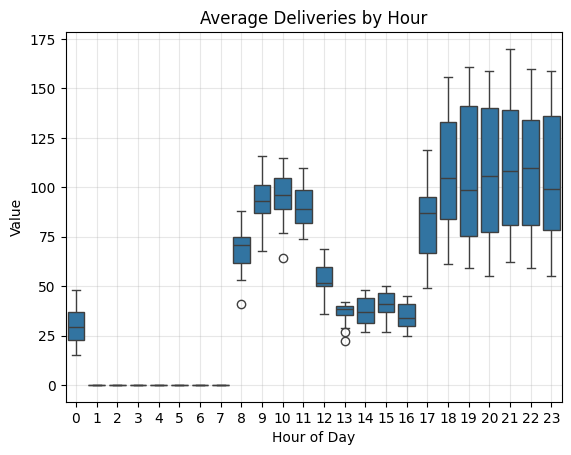

In [21]:
# plot the average deliveries by hour
daily_totals = df_copy.groupby(df_copy.index.date)['deliveries_this_hour'].transform('sum')

df_copy = df_copy[daily_totals > 0]

#create month and day variables 
df_copy['month'] = df_copy.index.month_name()
df_copy['day'] = df_copy.index.day

# Plotting the series
sns.boxplot(data=df_copy, x='hour', y='deliveries_this_hour')

# Clean up the labels
plt.title('Average Deliveries by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Value')
plt.xticks(range(0, 24)) # Ensures every hour is shown
plt.grid(True, alpha=0.3)

plt.show()

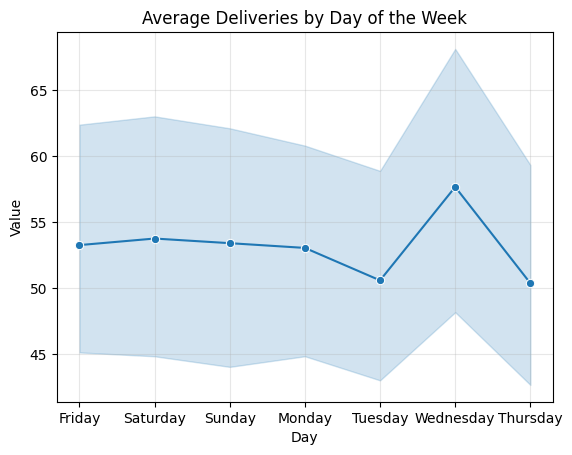

In [22]:
# plot the average deliveries by day of the week

# Plotting the series
sns.lineplot(data=df_copy, x='day_name', y='deliveries_this_hour', marker='o')

# Clean up the labels
plt.title('Average Deliveries by Day of the Week')
plt.xlabel('Day')
plt.ylabel('Value')
plt.xticks(range(0, 7)) # Ensures every hour is shown
plt.grid(True, alpha=0.3)

plt.show()

In [23]:
# ---- hypothesis testing #1----

# null = deliveries are equal across all hours
# alternative = at least one hour differs significantly 

# ---- hypothesis testing #2----

# null: There is no difference in day of the week demand
# alternative: There is a difference between day of the week
 
import statsmodels.formula.api as smf

mixed_model = smf.mixedlm("deliveries_this_hour ~ C(hour) + C(day_name)", data=df_copy, groups=df_copy.index.date).fit()
print(mixed_model.summary())

# we use mixed linear model instead of one way anova as it fixes time dependencies, because 8am correlates with 9am, etc.
# the results show that time of day has a statistically massive impact but day of week does not matter.
# because the hours have p < 0.05 but day of week have p > 0.05

                Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  deliveries_this_hour
No. Observations:   858      Method:              REML                
No. Groups:         44       Scale:               208.2694            
Min. group size:    15       Log-Likelihood:      -3493.7768          
Max. group size:    24       Converged:           Yes                 
Mean group size:    19.5                                              
----------------------------------------------------------------------
                          Coef.  Std.Err.   z    P>|z|  [0.025  0.975]
----------------------------------------------------------------------
Intercept                 30.826    5.669  5.437 0.000  19.715  41.938
C(hour)[T.1]             -30.000    3.077 -9.750 0.000 -36.030 -23.970
C(hour)[T.2]             -30.000    3.077 -9.750 0.000 -36.030 -23.970
C(hour)[T.3]             -30.000    3.077 -9.750 0.000 -36.030 -23.970
C(hour)[T.4]           

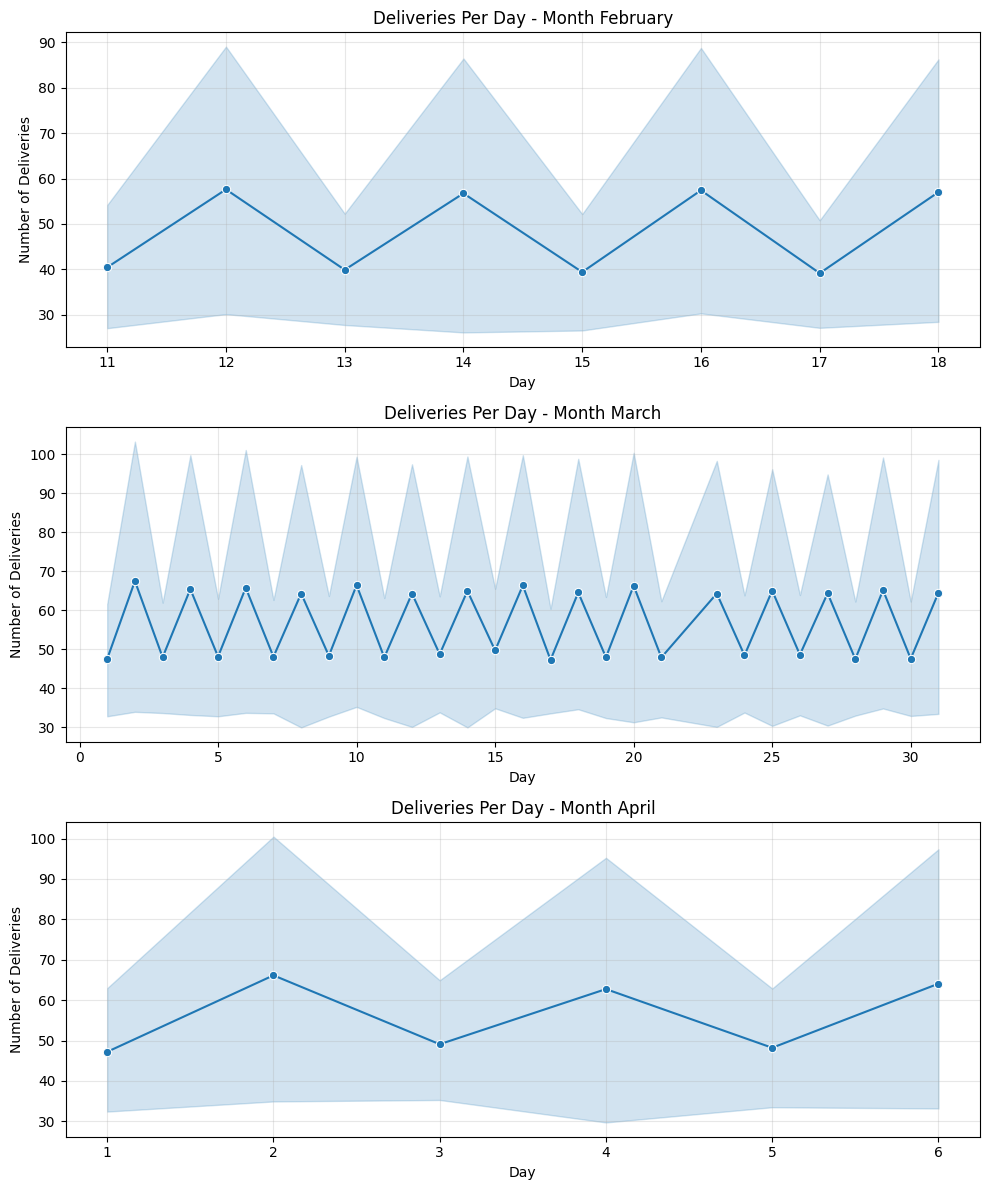

In [24]:
# ------ plot average deliveries per day per month -------

# Get unique months
months = df_copy['month'].unique()

#Create one subplot per month
fig, axes = plt.subplots(len(months), 1, figsize=(10, 12))

if len(months) == 1:
    axes = [axes]

for ax, month in zip(axes, months):

    # Filter month
    month_data = df_copy[df_copy['month'] == month]

    # Plot
    sns.lineplot(data=month_data, x='day', y='deliveries_this_hour', marker='o', ax=ax)

    # Titles and labels
    ax.set_title(f'Deliveries Per Day - Month {month}')
    ax.set_xlabel('Day')
    ax.set_ylabel('Number of Deliveries')
    
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [25]:
# ---- hypothesis #3 -----

# null = there is no statistical difference between the months
# alternative = there is a statistical difference between the months

# since we are comparing the mean deliveries across more than 2 groups we will use anova testing

from scipy.stats import f_oneway
from scipy.stats import kruskal
from scipy.stats import shapiro
from scipy.stats import levene

groups = [
    g['deliveries_this_hour'].values
    for _, g in df_copy.groupby('month')
]

anova_stat, anova_p = f_oneway(*groups)

print("ANOVA Statistic:", anova_stat)
print("P-value:", anova_p)

alpha = 0.05

#interpret the result
if anova_p < alpha:
    print("Reject H0")
    print("Deliveries differ significantly across months.")
else:
    print("Fail to reject H0")
    print("No significant monthly differences found.")
    
# month is statistically not significant

ANOVA Statistic: 1.7240837837740595
P-value: 0.17895578127046444
Fail to reject H0
No significant monthly differences found.


Weather: weather
3.0    522
4.0    336
Name: count, dtype: int64


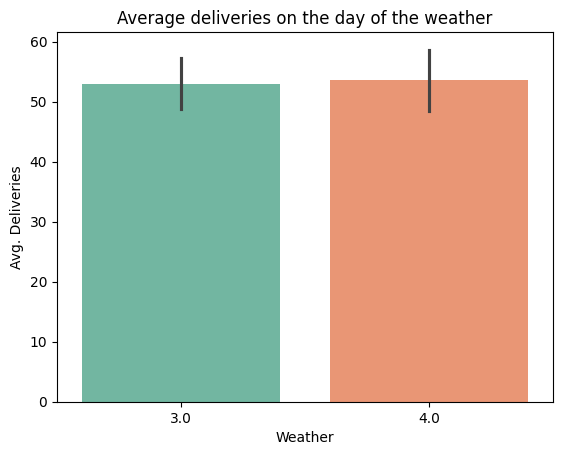

T-Test Statistic: -0.1976578436162449
P-value: 0.843359701051822
Fail to reject H0
No significant differences found the day of the weather.


In [26]:
# lets do hypothesis testing on the external variables or if they are just noise

# ----- WEATHER ------

print(f"Weather: {df_copy['weather'].value_counts()}")
# 3 == sunny, 4 == cloudy

ax = sns.barplot(data = df_copy, x = 'weather', y = 'deliveries_this_hour', hue='weather',palette='Set2',legend = False)
plt.title("Average deliveries on the day of the weather")
plt.ylabel('Avg. Deliveries')
plt.xlabel('Weather')
plt.show()

groups_weather = [
    g['deliveries_this_hour'].values
    for _, g in df_copy.groupby('weather')
]

t_stat, ttest_p = stats.ttest_ind(*groups_weather)

print("T-Test Statistic:", t_stat)
print("P-value:", ttest_p)

alpha = 0.05

#interpret the result
if ttest_p < alpha:
    print("Reject H0")
    print("Deliveries differ significantly depending on the weather.")
else:
    print("Fail to reject H0")
    print("No significant differences found the day of the weather.")
    
# weather is statistically not significant

Traffic: [1. 2. 3. 4.]


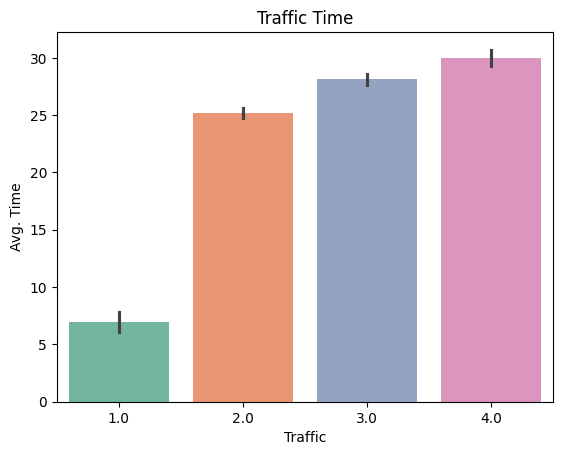

T-Test Statistic: 514.5496124302771
P-value: 6.867232920913161e-191
Reject H0
Traffic affects delivery time


In [27]:
# ----- TRAFFIC ------

print(f"Traffic: {df_copy['traffic'].unique()}")
#1 == low, 2 == medium, 3 == high, 4 == jam

ax = sns.barplot(data = df_copy, x = 'traffic', y = 'avg_time', hue='traffic', palette = 'Set2', legend=False)
plt.title("Traffic Time")
plt.ylabel('Avg. Time')
plt.xlabel('Traffic')
plt.show()

groups_traffic = [
    g['avg_time'].values
    for _, g in df_copy.groupby('traffic')
]

anova_stat, anova_p = f_oneway(*groups_traffic)

print("T-Test Statistic:", anova_stat)
print("P-value:", anova_p)

alpha = 0.05

#interpret the result
if anova_p < alpha:
    print("Reject H0")
    print("Traffic affects delivery time")
else:
    print("Fail to reject H0")
    print("Traffic does not affect delivery time")
    
# we can use lagged avg_time and traffic time to fit our model

Festival: 0.116


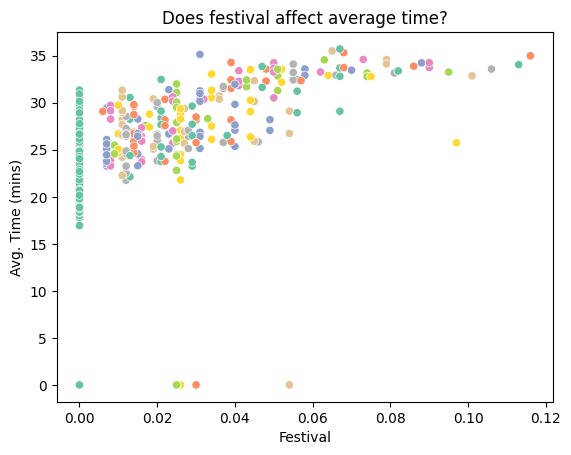

T-Test Statistic: 6.06861208225099
P-value: 1.201933539908425e-40
Reject H0
Festival affects delivery time


In [28]:
# ----- FESTIVAL ------

print(f"Festival: {df_copy['festival'].max()}")

bucket_boundaries = np.arange(0.0, 0.13, 0.02)

ax = sns.scatterplot(data = df_copy, x = 'festival', y = 'avg_time',hue='festival',palette='Set2',legend = False)
plt.title("Does festival affect average time?")
plt.ylabel('Avg. Time (mins)')
plt.xlabel('Festival')
plt.show()

groups_fesitval = [
    g['avg_time'].values
    for _, g in df_copy.groupby('festival')
]

anova_stat, anova_p = f_oneway(*groups_fesitval)

print("T-Test Statistic:", anova_stat)
print("P-value:", anova_p)

alpha = 0.05

#interpret the result
if anova_p < alpha:
    print("Reject H0")
    print("Festival affects delivery time")
else:
    print("Fail to reject H0")
    print("Festival does not affect delivery time")
    
# we can use festival to fit 

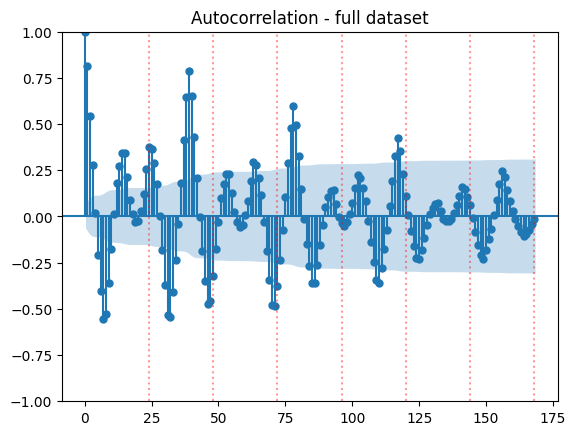

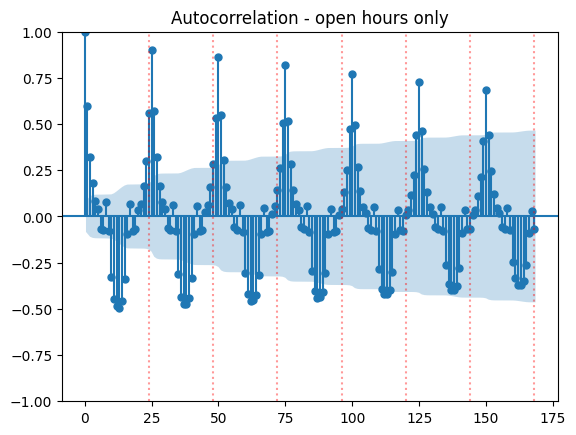

In [29]:
# next we will perform dependence and autocorrelation analysis on lag dependence and see..
# Does past demand contain useful information about current demand?

from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

open_df = driver_count[driver_count['is_open'] == 1] # test both full dataset and only where store is open

plot_acf(driver_count['drivers_this_hour'].dropna(), lags=168)
plt.title('Autocorrelation - full dataset')
# Add a vertical line at each multiple of 24 to act as a visual anchor
for lag in range(24, 169, 24):
    plt.axvline(x=lag, color='red', linestyle=':', alpha=0.4)
    
plt.show()

plot_acf(open_df['drivers_this_hour'].dropna(), lags=168)
plt.title('Autocorrelation - open hours only')
for lag in range(24, 169, 24):
    plt.axvline(x=lag, color='red', linestyle=':', alpha=0.4)
plt.show()

# The ACF plot shows strong autocorrelation at lag 1 and repeating peaks at multiples of 24 hours, 
# indicating that driver demand is highly dependent on recent demand and 
# follows a strong daily seasonal pattern

In [30]:
driver_count = driver_count.drop('day_name',axis=1)

In [31]:
# ------------------- FITTING THE MODEL ----------------------

In [32]:
# define the target and exogenous variables
y = driver_count['drivers_this_hour']
exog_cols = ['is_open'
             #,'traffic','festival'
            ]
exog = driver_count[exog_cols]

# split consistently
train = driver_count.iloc[:-168]
test = driver_count.iloc[-168:]

y_train = y.iloc[:-168]
y_test = y.iloc[-168:]

exog_train = exog.iloc[:-168]
exog_test = exog.iloc[-168:]

print(len(y_train))
print(len(exog_train))

1152
1152


In [33]:
#An ADF test was conducted to assess stationarity of the target series

from statsmodels.tsa.stattools import adfuller

# 1. Run the ADF test on your training data with interpolated data 
result = adfuller(driver_count['drivers_this_hour'].interpolate(method='time'))

# 2. Extract and print the key metrics
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")

driver_count

#Since the p-value was below the 0.05 significance level, this rejects the null hypothesis,..
#suggesting that the series is stationary. We will use d=0 in SarimaX model.

ADF Statistic: -3.0807
p-value: 0.0280


,deliveries_this_hour,avg_time,drivers_this_hour,hour,day_of_week,is_weekend,is_open,driver_lag_1,driver_lag_24,driver_lag_168,...,deliveries_lag_1,deliveries_lag_24,deliveries_lag_168,avg_time_lag_1,avg_time_lag_24,avg_time_lag_168,weather,traffic,festival,deliver_batch
dttm_floored,,,,,,,,,,,,,,,,,,,,,
2022-02-11 00:00:00,19.0,20.05,10.0,0,4,0,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,3.0,1.0,0.000,1.0
2022-02-11 01:00:00,0.0,0.00,0.0,1,4,0,0,10.0,NaN,NaN,...,19.0,NaN,NaN,20.05,NaN,NaN,3.0,1.0,0.000,0.0
2022-02-11 02:00:00,0.0,0.00,0.0,2,4,0,0,0.0,NaN,NaN,...,0.0,NaN,NaN,0.00,NaN,NaN,3.0,1.0,0.000,0.0
2022-02-11 03:00:00,0.0,0.00,0.0,3,4,0,0,0.0,NaN,NaN,...,0.0,NaN,NaN,0.00,NaN,NaN,3.0,1.0,0.000,0.0
2022-02-11 04:00:00,0.0,0.00,0.0,4,4,0,0,0.0,NaN,NaN,...,0.0,NaN,NaN,0.00,NaN,NaN,3.0,1.0,0.000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-04-06 19:00:00,142.0,33.46,71.0,19,2,0,1,63.0,45.0,39.0,...,126.0,89.0,78.0,29.16,26.66,26.35,3.0,3.0,0.070,1.0
2022-04-06 20:00:00,147.0,32.78,74.0,20,2,0,1,71.0,41.0,46.0,...,142.0,81.0,92.0,33.46,26.60,27.68,4.0,4.0,0.075,1.0
2022-04-06 21:00:00,116.0,32.18,58.0,21,2,0,1,74.0,35.0,45.0,...,147.0,70.0,90.0,32.78,26.49,26.61,3.0,4.0,0.052,1.0


In [34]:
# instead of manually guessing one SARIMA setup - we can setup candidate models
candidate_models = [
    # simple daily seasonal AR
    ((1,0,0), (1,1,0,24)), # since we can safely conclude that days of the week does not matter, we can keep the seasonal order as 24 instead of 168
    ((1,0,0), (2,1,0,24)),
    ((1,0,0), (1,1,1,24)),

    # add non-seasonal differencing
    ((1,1,0), (1,0,0,24)),
    ((1,1,0), (1,0,1,24)),
    ((1,1,0), (2,0,0,24)),

    # MA-style alternatives
    ((0,1,0), (1,0,0,24)),
    ((0,1,0), (1,0,1,24)),
    ((0,1,0), (2,0,0,24)),

    # slightly more flexible
#     ((1,1,0), (1,0,0,24)),
#     ((1,1,1), (1,0,1,24)),
#     ((1,1,1), (2,0,0,24)),
]

# test the model 
# using statespace model for Kalman Filter to handle missing values in y variable
from statsmodels.tsa.statespace.sarimax import SARIMAX 
from sklearn.metrics import mean_absolute_error, mean_squared_error

results_list = []

for order, seasonal_order in candidate_models:
    try:
        model = SARIMAX(
            y_train,
            exog=exog_train,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        fitted = model.fit(disp=False)

        forecast = fitted.forecast(
            steps=len(y_test),
            exog=exog_test
        )

        eval_df = pd.DataFrame({
            'actual': y_test,
            'forecast': forecast
        }).dropna()

        mae = mean_absolute_error(eval_df['actual'], eval_df['forecast'])
        rmse = np.sqrt(mean_squared_error(eval_df['actual'], eval_df['forecast']))

        results_list.append({
            'order': order,
            'seasonal_order': seasonal_order,
            'AIC': fitted.aic,
            'MAE': mae,
            'RMSE': rmse,
            'eval_rows': len(eval_df)
        })

    except Exception as e:
        print(f"Failed: {order}, {seasonal_order} -> {e}")

results_df = pd.DataFrame(results_list).sort_values('MAE')
results_df

C:\Users\jband\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,order,seasonal_order,AIC,MAE,RMSE,eval_rows
0,"(1, 0, 0)","(1, 1, 0, 24)",4825.915510,3.118801,5.179971,132
1,"(1, 0, 0)","(2, 1, 0, 24)",4653.257261,3.260515,5.352236,132
2,"(1, 0, 0)","(1, 1, 1, 24)",4713.895410,3.583964,5.898608,132
5,"(1, 1, 0)","(2, 0, 0, 24)",4977.907930,5.293358,6.784726,132
8,"(0, 1, 0)","(2, 0, 0, 24)",5149.593964,7.407460,8.643030,132
4,"(1, 1, 0)","(1, 0, 1, 24)",5143.940433,19.801213,21.683900,132
7,"(0, 1, 0)","(1, 0, 1, 24)",5247.563731,20.531906,22.340624,132
6,"(0, 1, 0)","(1, 0, 0, 24)",5797.576085,64.894096,68.354767,132
3,"(1, 1, 0)","(1, 0, 0, 24)",5757.664521,65.404322,68.776456,132


In [35]:
#Rolling time-series cross-validation was used to test ..
#..the selected SARIMAX model across multiple 168-hour forecast windows

# fixed best SARIMAX parameters
order = (1, 0, 0)
seasonal_order = (1, 1, 0, 24)

forecast_horizon = 168
initial_train_size = int(len(driver_count) * 0.4)

cv_scores = []

for train_end in range(
    initial_train_size,
    len(driver_count) - forecast_horizon,
    forecast_horizon
):
    
    y_train_cv = y.iloc[:train_end]
    y_test_cv = y.iloc[train_end:train_end + forecast_horizon]

    exog_train_cv = exog.iloc[:train_end]
    exog_test_cv = exog.iloc[train_end:train_end + forecast_horizon]

    try:
        model = SARIMAX(
            y_train_cv,
            exog=exog_train_cv,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False,
            missing='none'
        )

        results = model.fit(disp=False)

        forecast = results.forecast(
            steps=len(y_test_cv),
            exog=exog_test_cv
        )

        eval_df_cv = pd.DataFrame({
            'actual': y_test_cv,
            'forecast': forecast
        }).dropna()

        mae = mean_absolute_error(
            eval_df_cv['actual'],
            eval_df_cv['forecast']
        )

        rmse = np.sqrt(
            mean_squared_error(
                eval_df_cv['actual'],
                eval_df_cv['forecast']
            )
        )

        cv_scores.append({
            'train_end': y.index[train_end],
            'test_start': y_test_cv.index[0],
            'test_end': y_test_cv.index[-1],
            'MAE': mae,
            'RMSE': rmse,
            'eval_rows': len(eval_df_cv)
        })

    except Exception as e:
        print(f"Fold failed at {y.index[train_end]}: {e}")

In [36]:
#view the cross-validation results

cv_scores_df = pd.DataFrame(cv_scores)

relative_error = cv_scores_df['MAE'].mean() / np.mean(y_test)

print(cv_scores_df)
print("Average CV MAE:", cv_scores_df['MAE'].mean())
print("Average CV RMSE:", cv_scores_df['RMSE'].mean())
print("Relative MAE (as % of mean):", relative_error * 100)

# we see that there is an outlier fold with 7.154 MAE

   train_end test_start            test_end       MAE       RMSE  eval_rows
0 2022-03-05 2022-03-05 2022-03-11 23:00:00  3.235251   5.064464        141
1 2022-03-12 2022-03-12 2022-03-18 23:00:00  3.058588   4.884467        132
2 2022-03-19 2022-03-19 2022-03-25 23:00:00  7.154304  12.993704        124
3 2022-03-26 2022-03-26 2022-04-01 23:00:00  3.322810   4.893154        141
Average CV MAE: 4.19273823495529
Average CV RMSE: 6.958947462630815
Relative MAE (as % of mean): 15.018763826705516


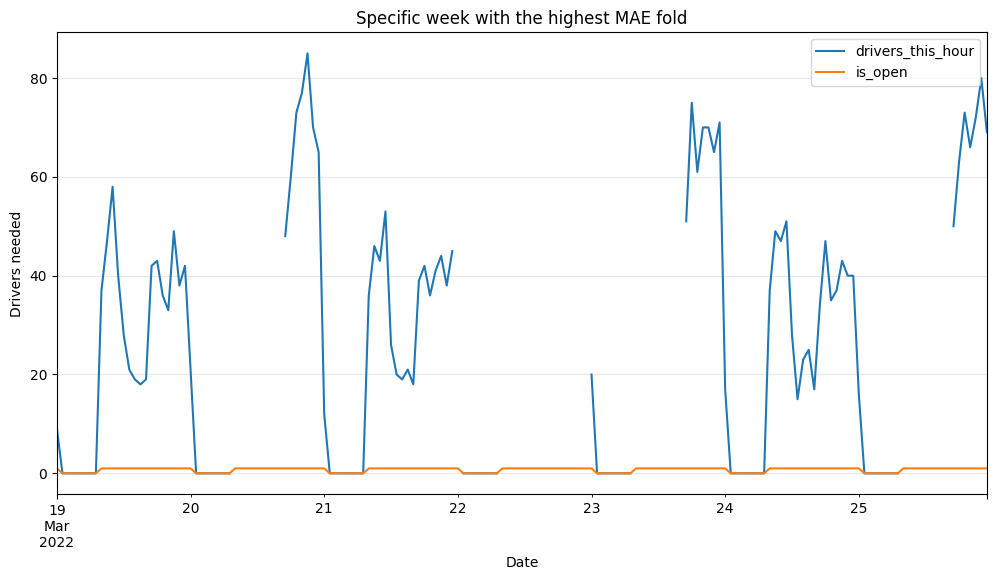

In [37]:
# lets take a look at the specific fold

bad_fold = cv_scores_df.sort_values('MAE', ascending=False).iloc[0]

bad_start = bad_fold['test_start']
bad_end = bad_fold['test_end']

driver_count.loc[bad_start:bad_end][
    ['drivers_this_hour', 'is_open']
].plot(figsize=(12,6))

plt.title("Specific week with the highest MAE fold")
plt.ylabel('Drivers needed')
plt.xlabel('Date')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#we can see that there a lot of missing data here

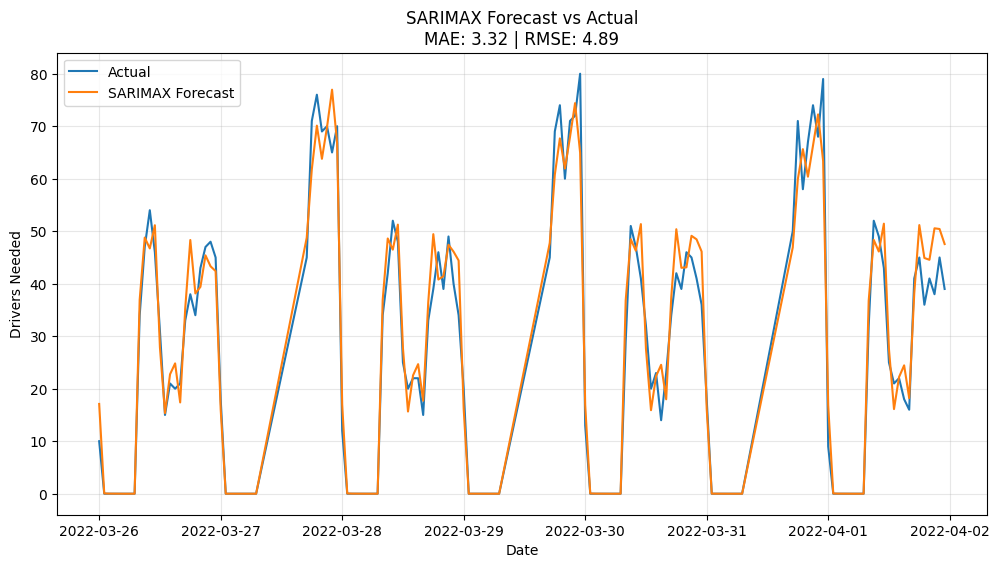

In [38]:
#Plot predictions on the last run of the cross validation step

plt.figure(figsize=(12,6))

plt.plot(eval_df_cv['actual'], label='Actual',)

plt.plot(eval_df_cv['forecast'], label='SARIMAX Forecast',)

plt.title(f"SARIMAX Forecast vs Actual\nMAE: {mae:.2f} | RMSE: {rmse:.2f}")

plt.xlabel("Date")
plt.ylabel("Drivers Needed")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [39]:
# evaluate naive model

# seasonal naive forecast (same hour yesterday)
naive_forecast = y.shift(168)

# align both series
naive_eval = pd.DataFrame({
    "actual": y_test,
    "naive": naive_forecast
}).dropna()

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

naive_mae = mean_absolute_error(
    naive_eval["actual"],
    naive_eval["naive"]
)

naive_rmse = np.sqrt(
    mean_squared_error(
        naive_eval["actual"],
        naive_eval["naive"]
    )
)

print("Naive MAE:", naive_mae)
print("Naive RMSE:", naive_rmse)

Naive MAE: 12.723809523809523
Naive RMSE: 19.134113141566967


In [40]:
# Compare SARIMAX vs naive

print("\n--- Model Comparison ---")
print("SARIMAX MAE:", cv_scores_df['MAE'].mean())
print("Naive MAE:", naive_mae)

print("\nImprovement (%):")
print((naive_mae - mae) / naive_mae * 100)


--- Model Comparison ---
SARIMAX MAE: 4.19273823495529
Naive MAE: 12.723809523809523

Improvement (%):
73.88510446342812


In [41]:
#------------- lets try another SarimaX model but interpolate the dataset --------

driver_count_copy = driver_count.copy()

driver_count_copy['deliveries_this_hour'] = driver_count_copy['deliveries_this_hour'].interpolate(method='time')

# refit all the features again

driver_count_copy['drivers_this_hour'] = np.ceil(driver_count_copy['deliveries_this_hour'] / capacity_per_driver)

driver_count_copy['driver_lag_1'] = driver_count_copy['drivers_this_hour'].shift(1)
driver_count_copy['driver_lag_24'] = driver_count_copy['drivers_this_hour'].shift(24)
driver_count_copy['driver_lag_168'] = driver_count_copy['drivers_this_hour'].shift(168)

driver_count_copy['deliveries_lag_1'] = driver_count_copy['deliveries_this_hour'].shift(1)
driver_count_copy['deliveries_lag_24'] = driver_count_copy['deliveries_this_hour'].shift(24)
driver_count_copy['deliveries_lag_168'] = driver_count_copy['deliveries_this_hour'].shift(168)

#we need interpolated avg_time
driver_count_copy['avg_time'] = dt.groupby('dttm_floored')['Time_taken(min)'].mean().round(2)
driver_count_copy['avg_time'] = driver_count_copy['avg_time'].interpolate(method='time')
driver_count_copy['avg_time_lag_1'] = driver_count_copy['avg_time'].shift(1)
driver_count_copy['avg_time_lag_24'] = driver_count_copy['avg_time'].shift(24)


# since we will use only deliveries_lag_24, we need to skip the first 24 records due to NAN

driver_count_copy = driver_count_copy.iloc[24:].copy()

driver_count_copy.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1296 entries, 2022-02-12 00:00:00 to 2022-04-06 23:00:00
Freq: h
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   deliveries_this_hour    1296 non-null   float64
 1   avg_time                1296 non-null   float64
 2   drivers_this_hour       1296 non-null   float64
 3   hour                    1296 non-null   int32  
 4   day_of_week             1296 non-null   int32  
 5   is_weekend              1296 non-null   int32  
 6   is_open                 1296 non-null   int32  
 7   driver_lag_1            1296 non-null   float64
 8   driver_lag_24           1296 non-null   float64
 9   driver_lag_168          1152 non-null   float64
 10  driver_rolling_mean_24  329 non-null    float64
 11  driver_rolling_std_24   329 non-null    float64
 12  deliveries_lag_1        1296 non-null   float64
 13  deliveries_lag_24       1296 non-null   float64
 

In [42]:
# fit the model using the new dataframe

# define the target and exogenous variables
y_copy = driver_count_copy['drivers_this_hour']
exog_cols_copy = ['is_open' 
                  ,'deliveries_lag_24'
             #'deliveries_lag_1','traffic','festival',
                  #'deliveries_lag_168', 'driver_lag_1', 'driver_lag_24','driver_lag_168',
                  #'avg_time_lag_1','avg_time_lag_24'
            ]
exog_copy = driver_count_copy[exog_cols_copy]

# split consistently
train_copy = driver_count_copy.iloc[:-168]
test_copy = driver_count_copy.iloc[-168:]

y_train_copy = y_copy.iloc[:-168]
y_test_copy = y_copy.iloc[-168:]

exog_train_copy = exog_copy.iloc[:-168]
exog_test_copy = exog_copy.iloc[-168:]

# instead of manually guessing one SARIMA setup - we can setup candidate models
candidate_models_copy = [
    # simple daily seasonal AR
    ((1,0,0), (1,1,0,24)),
    ((1,0,0), (2,1,0,24)),
    ((1,0,0), (1,1,1,24)),

    # add non-seasonal differencing
    ((1,1,0), (1,0,0,24)),
    ((1,1,0), (1,0,1,24)),
    ((1,1,0), (2,0,0,24)),

    # MA-style alternatives
    ((0,1,0), (1,0,0,24)),
    ((0,1,0), (1,0,1,24)),
    ((0,1,0), (2,0,0,24)),

    # slightly more flexible
#     ((1,1,1), (1,0,0,24)),
#     ((1,1,1), (1,0,1,24)),
#     ((1,1,1), (2,0,0,24)),
]

In [43]:
# test the model 

results_list_copy = []

for order, seasonal_order in candidate_models_copy:
    try:
        model = SARIMAX(
            y_train_copy,
            exog=exog_train_copy,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        fitted = model.fit(disp=False)

        forecast_copy = fitted.forecast(
            steps=len(test_copy),
            exog=exog_test_copy
        )

        eval_df_copy = pd.DataFrame({
            'actual': y_test_copy,
            'forecast': forecast_copy
        }).dropna()

        mae = mean_absolute_error(eval_df_copy['actual'], eval_df_copy['forecast'])
        rmse = np.sqrt(mean_squared_error(eval_df_copy['actual'], eval_df_copy['forecast']))

        results_list_copy.append({
            'order': order,
            'seasonal_order': seasonal_order,
            'AIC': fitted.aic,
            'MAE': mae,
            'RMSE': rmse,
            'eval_rows': len(eval_df_copy)
        })

    except Exception as e:
        print(f"Failed: {order}, {seasonal_order} -> {e}")

results_df_copy = pd.DataFrame(results_list_copy).sort_values('MAE')
results_df_copy

,order,seasonal_order,AIC,MAE,RMSE,eval_rows
2,"(1, 0, 0)","(1, 1, 1, 24)",7078.218029,4.446071,6.160183,168
1,"(1, 0, 0)","(2, 1, 0, 24)",6911.514654,4.678571,6.195853,168
0,"(1, 0, 0)","(1, 1, 0, 24)",7114.010249,4.803986,6.321729,168
5,"(1, 1, 0)","(2, 0, 0, 24)",7134.837559,7.087911,10.184301,168
8,"(0, 1, 0)","(2, 0, 0, 24)",7169.836542,7.742028,11.053750,168
3,"(1, 1, 0)","(1, 0, 0, 24)",7285.550413,9.247542,12.609751,168
6,"(0, 1, 0)","(1, 0, 0, 24)",7323.689586,9.723333,13.116189,168
4,"(1, 1, 0)","(1, 0, 1, 24)",7281.671928,10.069350,13.786588,168
7,"(0, 1, 0)","(1, 0, 1, 24)",7310.386561,10.766905,14.651397,168


In [44]:
#Rolling time-series cross-validation was used to test ..
#..the selected SARIMAX model across multiple 168-hour forecast windows

# fixed best SARIMAX parameters
order = (1, 0, 0)
seasonal_order = (1, 1, 1, 24)

forecast_horizon = 168
initial_train_size = int(len(driver_count_copy) * 0.4)

cv_scores_copy = []

for train_end in range(
    initial_train_size,
    len(driver_count_copy) - forecast_horizon,
    forecast_horizon
):
    
    y_train_cv = y_copy.iloc[:train_end]
    y_test_cv = y_copy.iloc[train_end:train_end + forecast_horizon]

    exog_train_cv = exog_copy.iloc[:train_end]
    exog_test_cv = exog_copy.iloc[train_end:train_end + forecast_horizon]

    try:
        model = SARIMAX(
            y_train_cv,
            exog=exog_train_cv,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False,
            missing='none'
        )

        results = model.fit(disp=False)

        forecast = results.forecast(
            steps=len(y_test_cv),
            exog=exog_test_cv
        )

        eval_df_cv_copy = pd.DataFrame({
            'actual': y_test_cv,
            'forecast': forecast
        }).dropna()

        mae = mean_absolute_error(
            eval_df_cv_copy['actual'],
            eval_df_cv_copy['forecast']
        )

        rmse = np.sqrt(
            mean_squared_error(
                eval_df_cv_copy['actual'],
                eval_df_cv_copy['forecast']
            )
        )

        cv_scores_copy.append({
            'train_end': y.index[train_end],
            'test_start': y_test_cv.index[0],
            'test_end': y_test_cv.index[-1],
            'MAE': mae,
            'RMSE': rmse,
            'eval_rows': len(eval_df_cv_copy)
        })

    except Exception as e:
        print(f"Fold failed at {y.index[train_end]}: {e}")

In [45]:
#view the cross-validation results

cv_scores_df_copy = pd.DataFrame(cv_scores_copy)

relative_error = cv_scores_df['MAE'].mean() / np.mean(y_test)

print(cv_scores_df_copy)

print("Average CV MAE:", cv_scores_df_copy['MAE'].mean())
print("Average CV RMSE:", cv_scores_df_copy['RMSE'].mean())
print("Relative MAE (as % of mean):", relative_error * 100)

# we can see there is an outlier MAE score of 9  

            train_end          test_start            test_end       MAE  \
0 2022-03-04 14:00:00 2022-03-05 14:00:00 2022-03-12 13:00:00  4.973412   
1 2022-03-11 14:00:00 2022-03-12 14:00:00 2022-03-19 13:00:00  4.495162   
2 2022-03-18 14:00:00 2022-03-19 14:00:00 2022-03-26 13:00:00  9.218420   
3 2022-03-25 14:00:00 2022-03-26 14:00:00 2022-04-02 13:00:00  3.373078   

        RMSE  eval_rows  
0   6.928075        168  
1   6.740070        168  
2  16.193170        168  
3   5.123236        168  
Average CV MAE: 5.515018050221092
Average CV RMSE: 8.746137717803276
Relative MAE (as % of mean): 15.018763826705516


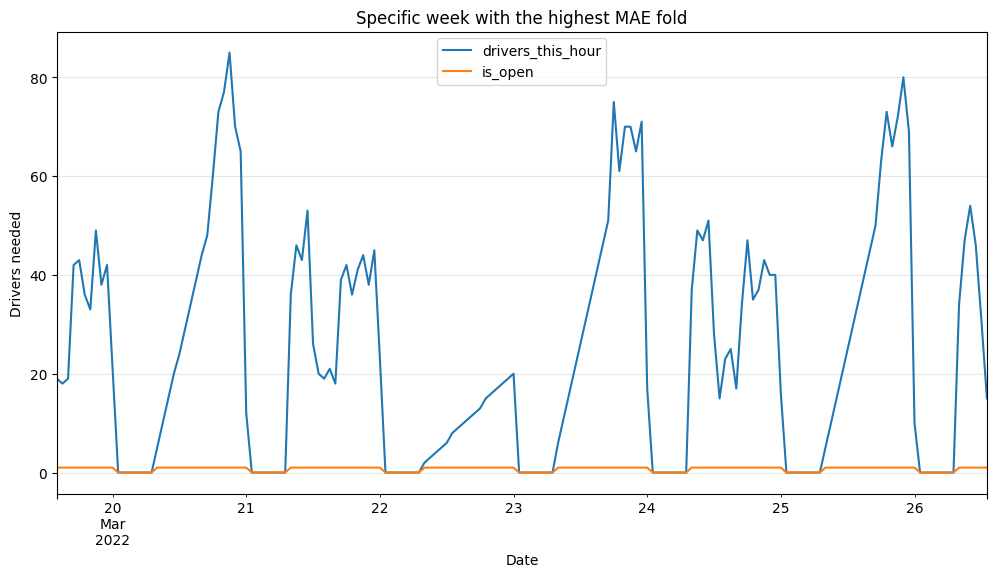

In [46]:
# lets take a look at the specific fold

bad_fold_copy = cv_scores_df_copy.sort_values('MAE', ascending=False).iloc[0]

bad_start_copy = bad_fold_copy['test_start']
bad_end_copy = bad_fold_copy['test_end']

driver_count_copy.loc[bad_start_copy:bad_end_copy][
    ['drivers_this_hour', 'is_open']
].plot(figsize=(12,6))

plt.title("Specific week with the highest MAE fold")
plt.ylabel('Drivers needed')
plt.xlabel('Date')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# We can see the interpolation in effect here compared to the previous SarimaX model

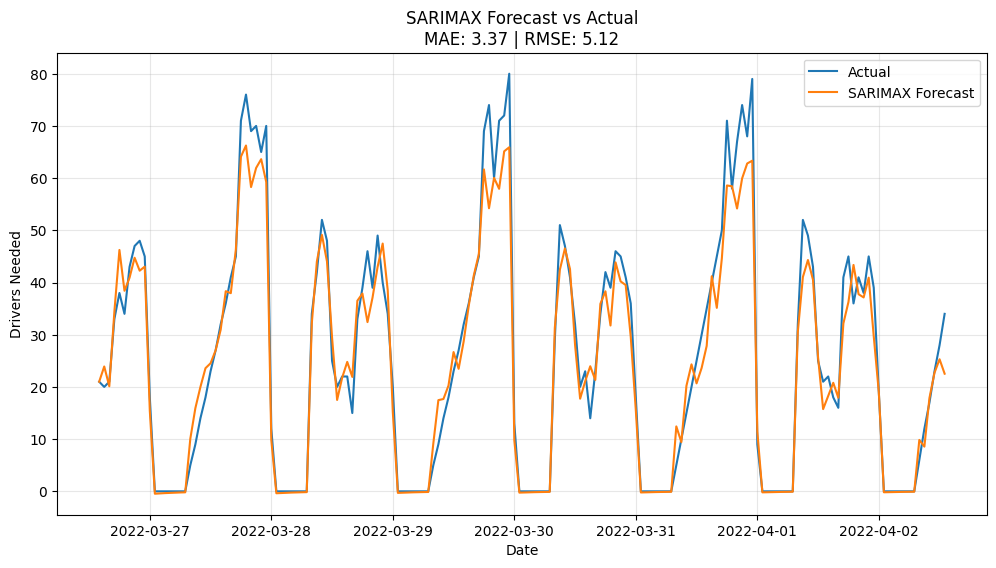

In [47]:
#Plot predictions on the last run of the cross validation step

plt.figure(figsize=(12,6))

plt.plot(eval_df_cv_copy['actual'], label='Actual',)

plt.plot(eval_df_cv_copy['forecast'], label='SARIMAX Forecast',)

plt.title(f"SARIMAX Forecast vs Actual\nMAE: {mae:.2f} | RMSE: {rmse:.2f}")

plt.xlabel("Date")
plt.ylabel("Drivers Needed")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [48]:
# evaluate naive model

# seasonal naive forecast (same hour yesterday)
naive_forecast = y_copy.shift(168)

# align both series
naive_eval = pd.DataFrame({
    "actual": y_test_copy,
    "naive": naive_forecast
}).dropna()

naive_mae = mean_absolute_error(
    naive_eval["actual"],
    naive_eval["naive"]
)

naive_rmse = np.sqrt(
    mean_squared_error(
        naive_eval["actual"],
        naive_eval["naive"]
    )
)

print("Naive MAE:", naive_mae)
print("Naive RMSE:", naive_rmse)

Naive MAE: 16.386904761904763
Naive RMSE: 21.61142224446534


In [49]:
# Compare SARIMAX vs naive

print("\n--- Model Comparison ---")
print("SARIMAX MAE:", cv_scores_df_copy['MAE'].mean())
print("Naive MAE:", naive_mae)

print("\nImprovement (%):")
print((naive_mae - cv_scores_df_copy['MAE'].mean()) / naive_mae * 100)


--- Model Comparison ---
SARIMAX MAE: 5.515018050221092
Naive MAE: 16.386904761904763

Improvement (%):
66.34496794634424


In [50]:
# --------------- XGBOOST -------------

In [51]:
# Next we will build our second model which is XGBOOST

# we need to use the interpolated dataset from previous to fix NAN values as our Y cannot handle NAN

# we didn't include this before
driver_count_copy['avg_time_lag_168'] = driver_count_copy['avg_time'].shift(144) 

driver_count_copy2 = driver_count_copy.iloc[144:].copy() # since driver_count_copy has already been..
# .. spliced for the first 24 records. 168 - 24 = 144

# decide the features to use
# we will not use these 'driver_lag_1','deliveries_lag_1', 'avg_time_lag_1'
features = ['is_open', 'driver_lag_24', 'driver_lag_168',
            'deliveries_lag_24', 'deliveries_lag_168',
            'avg_time_lag_24', 'avg_time_lag_168',
            'traffic', 'festival'
           ]

#create the target

y = driver_count_copy2['drivers_this_hour']

# split consistently
train = driver_count_copy2.iloc[:-168]
test = driver_count_copy2.iloc[-168:]

y_train = train['drivers_this_hour']
y_test = test['drivers_this_hour']

x_train = train[features]
x_test = test[features]

print(x_train.isna().sum())
print(y_train.isna().sum())

is_open               0
driver_lag_24         0
driver_lag_168        0
deliveries_lag_24     0
deliveries_lag_168    0
avg_time_lag_24       0
avg_time_lag_168      0
traffic               0
festival              0
dtype: int64
0


In [52]:
driver_count_copy2.info() # has 1152 records. 1320 - 168 = 1152

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1152 entries, 2022-02-18 00:00:00 to 2022-04-06 23:00:00
Freq: h
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   deliveries_this_hour    1152 non-null   float64
 1   avg_time                1152 non-null   float64
 2   drivers_this_hour       1152 non-null   float64
 3   hour                    1152 non-null   int32  
 4   day_of_week             1152 non-null   int32  
 5   is_weekend              1152 non-null   int32  
 6   is_open                 1152 non-null   int32  
 7   driver_lag_1            1152 non-null   float64
 8   driver_lag_24           1152 non-null   float64
 9   driver_lag_168          1152 non-null   float64
 10  driver_rolling_mean_24  281 non-null    float64
 11  driver_rolling_std_24   281 non-null    float64
 12  deliveries_lag_1        1152 non-null   float64
 13  deliveries_lag_24       1152 non-null   float64
 

In [53]:
#Fit XGBoost

from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(x_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [54]:
predictions = model.predict(x_test)

mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(
    mean_squared_error(y_test, predictions)
)

print(mae)
print(rmse)

5.257613542223615
8.367120919334948


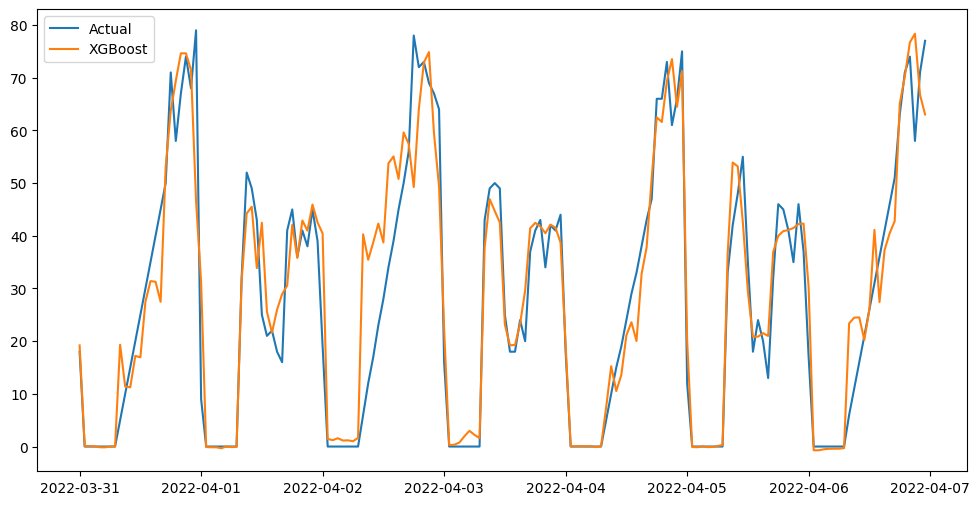

In [55]:
plt.figure(figsize=(12,6))

plt.plot(y_test.index, y_test, label='Actual')
plt.plot(y_test.index, predictions, label='XGBoost')

plt.legend()
plt.show()

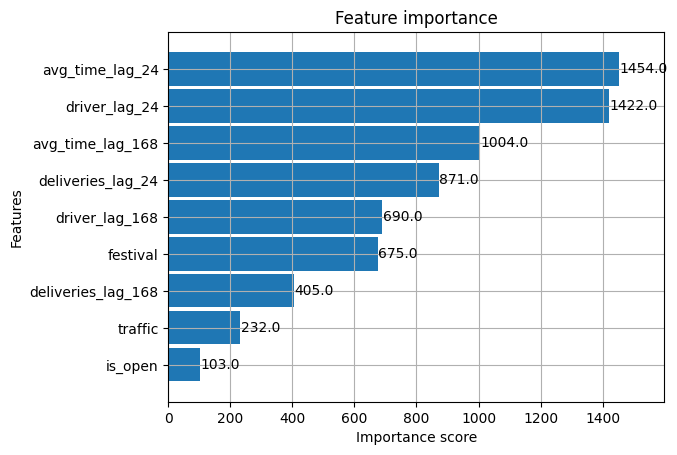

In [56]:
from xgboost import plot_importance

_ = plot_importance(model, height=0.9)

In [57]:
# XGBOOST first result - so our first initial run we received mae score of 5.711723479165119

# so lets hypertune the model

#XGBoost hyperparameters were optimized using Grid Search with Time Series Cross Validation. 
#The search evaluated combinations of tree depth (max_depth), number of trees (n_estimators), 
#and learning rate (learning_rate). 
#The configuration producing the lowest mean absolute error across validation folds was 
#selected as the final model

In [58]:
# use time series cross validation

from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import GridSearchCV

tscv = TimeSeriesSplit(n_splits=5)

#hypertune the model 

param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1]
}

#run the grid search

model = XGBRegressor(
    objective='reg:squarederror', #regression objective used for Demand forecasting
    random_state=42
)

grid = GridSearchCV(
    model,
    param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error'
)

grid.fit(x_train, y_train)

print(grid.best_params_)

print(-grid.best_score_)

{'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100}
7.4900799940737475


In [59]:
# learning rate = 0.05 = The model learns gradually.
# max depth = 7 = The model preferred fairly complex trees.
# n_estimators = 100 = The model needed around 100 trees before performance stopped improving.

MAE: 5.186815775389689
RMSE: 10.190291592754718


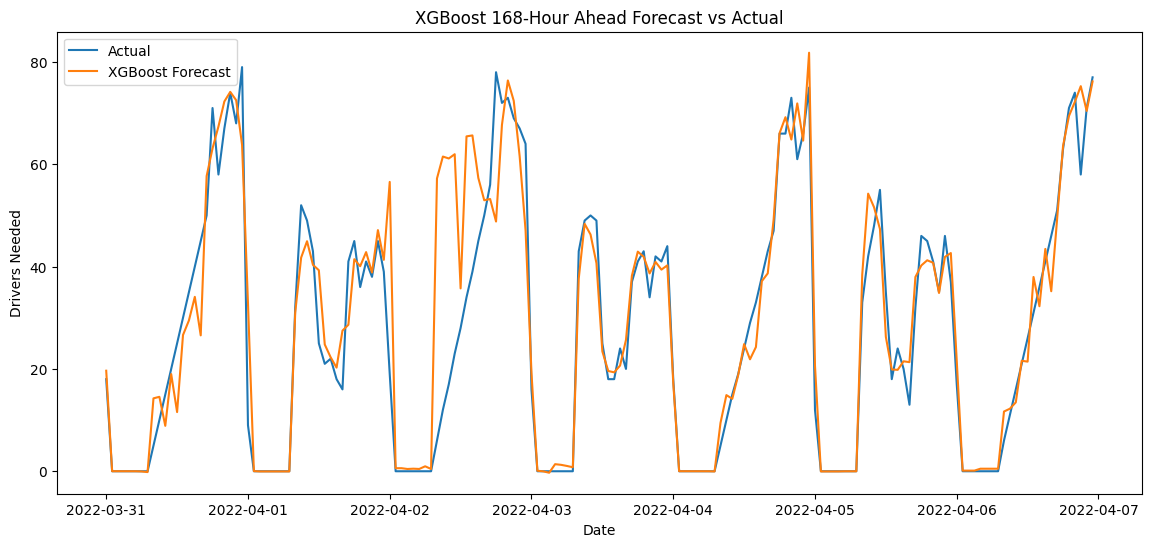

In [60]:
# get the mae on the best parameter

best_xgb = grid.best_estimator_ # Fully trained model using those best hyperparameters

pred = best_xgb.predict(x_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))

print("MAE:", mae)
print("RMSE:", rmse)

plt.figure(figsize=(14,6))
plt.plot(y_test.index, y_test, label='Actual')
plt.plot(y_test.index, pred, label='XGBoost Forecast')

plt.title('XGBoost 168-Hour Ahead Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Drivers Needed')
plt.legend()
plt.show()

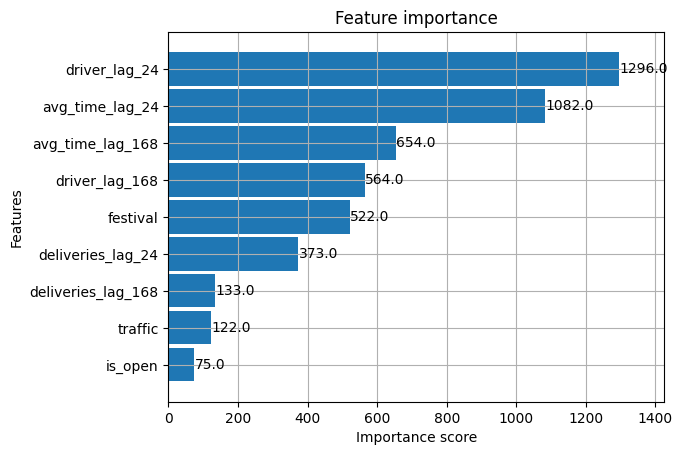

In [61]:
#feature importance plot of the grid search

_ = plot_importance(best_xgb, height=0.9)

In [62]:
driver_count_copy2['drivers_this_hour'].mean() 

# 5.1 is great for the relative error of 21 drivers.

21.186631944444443

In [66]:
# -------------- COMPARE ---------------- #

# Since the first model of SarimaX did not use the full dataset as there were missing values,..
# it is not a fair comparison to the SarimaX B and XGBoost model.

comparison = pd.DataFrame({
    'Model': ['SARIMAX A - NaNs preserved','SARIMAX B - interpolated','XGBoost - interpolated'],
    'MAE': [4.20, 5.52, 5.19]
})

comparison

#SARIMAX A was selected as the final model because it achieved the lowest MAE of 4.20. 
#Unlike the interpolated SARIMAX B and XGBoost models, SARIMAX A preserved genuine missing 
#target observations, allowing the model to maintain the original temporal structure of the data. 
#This suggests that interpolation may have introduced artificial patterns that reduced forecasting accuracy.

,Model,MAE
0,SARIMAX A - NaNs preserved,4.20
1,SARIMAX B - interpolated,5.52
2,XGBoost - interpolated,5.19


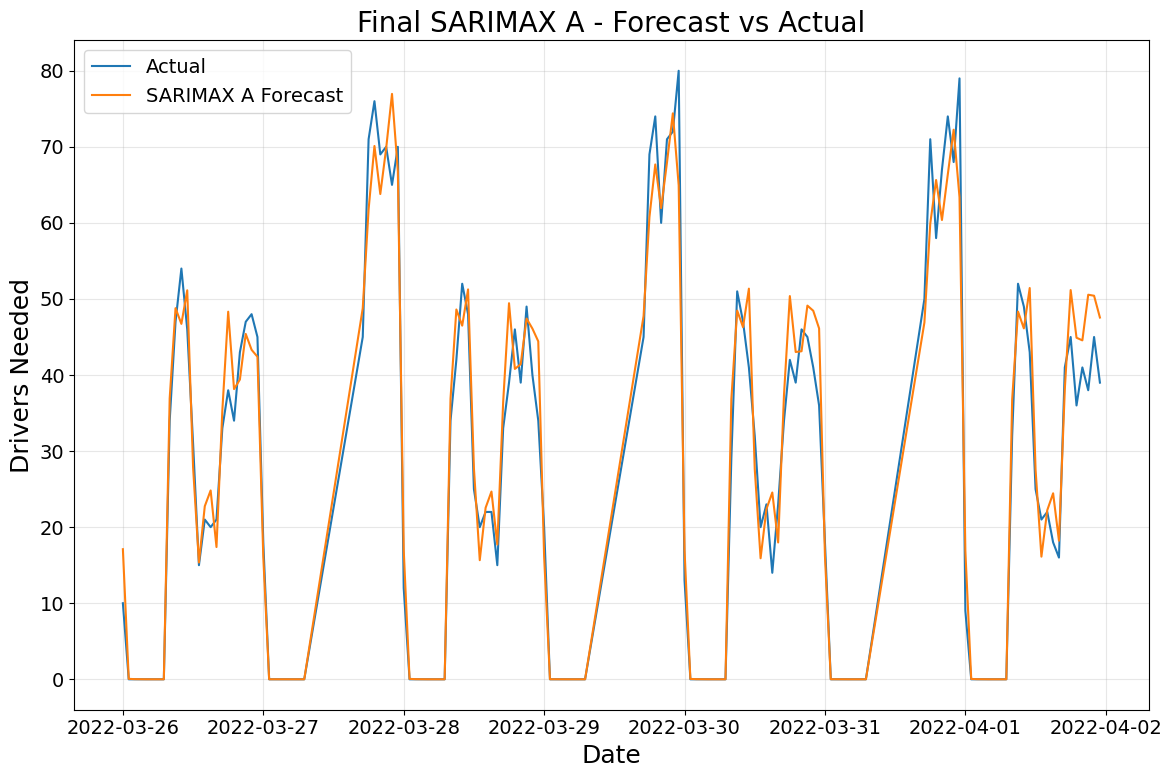

In [88]:
# plot the top model

plt.figure(figsize=(12,8))

plt.plot(eval_df_cv['actual'], label='Actual')
plt.plot(eval_df_cv['forecast'], label='SARIMAX A Forecast')


plt.title('Final SARIMAX A - Forecast vs Actual', fontsize = 20)
plt.xlabel('Date', fontsize = 18)
plt.ylabel('Drivers Needed', fontsize = 18)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
#------ Conclusion notes ---------

#SARIMAX B and XGBoost were originally evaluated on 168 forecast periods, 
#whereas SARIMAX A could only be evaluated on 132 periods due to missing exogenous observations.

#To ensure fair model comparison, all forecasts were aligned to the same 132 timestamps before 
#calculating performance metrics.

# -----
# SARIMAX A achieved the best overall performance. 

# XGBoost achieved competitive performance when evaluated on the same forecast periods, ..
#..suggesting that both statistical and machine learning approaches were effective. 

# However, the superior performance of SARIMAX indicates that the driver demand series is ..
#..primarily driven by temporal and seasonal dependencies that are well captured by classical ..
#..time-series modelling techniques.